# I. Importing the Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import requests
import string
from collections import Counter

In [2]:
RED = "\033[31;1m"
YELLOW = "\033[32;1m"
GREEN = "\033[33;1m"
BLUE = "\033[34;1m"
PURPLE ="\033[35;1m"
CYAN = "\033[36;1m"
WHITE = "\033[37;1m"
ORANGE = "\033[38;5;208m"

# II. Setting up the device

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

Using Device: cuda


# III. Loading the Dataset

In [4]:
def download_data():
  url = "https://www.gutenberg.org/files/11/11-0.txt"
  response = requests.get(url)
  text = response.text

  # Find the start and the end of the actual book content
  start = text.find("CHAPTER I")
  end = text.find("THE END")

  if start == -1:
    start = 0
  if end == -1:
    end = len(text)

  text = text[start:end+1]
  return text

# IV. Preprocessing of the data

In [5]:
def preprocess_text(text):
  # Convert to lowercase and keep only letters, spaces and basic punctuation
  allowed_chars = string.ascii_lowercase + string.digits + ".,!?'-\n"
  text = "".join([char.lower() if char.lower() in allowed_chars else " " for char in text])

  # Removing whitespaces
  text = " ".join(text.split())
  return text

In [6]:
# Creating character mapping
def create_mappings(text):
  chars = sorted(list(set(text)))
  char_to_idx = {char:i for i, char in enumerate(chars)}
  idx_to_char = {i:char for i, char in enumerate(chars)}

  return chars, char_to_idx, idx_to_char

In [7]:
# Create training sequences
def create_sequence(text, char_to_idx, seq_length=100):
  sequences = []
  targets = []

  for i in range(len(text) - seq_length):
    seq = text[i:i + seq_length]
    target = text[i + 1: i + seq_length + 1]

    sequences.append([char_to_idx[char] for char in seq])
    targets.append([char_to_idx[char] for char in target])

  return np.array(sequences), np.array(targets)

# V. Training the Neural Network

In [8]:
class SimpleRNN(nn.Module):
  def __init__(self, vocab_size:int, hidden_size:int, num_layers=2) -> None:
    super(SimpleRNN, self).__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    self.vocab_size = vocab_size

    # Embedding layer
    self.embeddings = nn.Embedding(vocab_size, hidden_size)

    # RNN Layer
    self.rnn = nn.RNN(hidden_size, hidden_size, num_layers, batch_first=True)

    # Output Layer
    self.fc = nn.Linear(hidden_size, vocab_size)

  def forward(self, x, hidden=None):
    # x shape- (batch_size, seq_length)
    batch_size = x.size(0)

    # Intialize the hidden layer if not provided
    if hidden is None:
      hidden = self.init_hidden(batch_size)

    # Embedding
    embedded = self.embeddings(x) # (batch_size, seq_length, hidden_size)

    # RNN
    output, hidden = self.rnn(embedded, hidden) # Output: (batch_size, seq_length, hidden_size)

    # Reshape for Linear Layer
    output = output.reshape(-1, self.hidden_size) # Output: (batch_size * seq_length, hidden_size)

    # Output Layer
    output = self.fc(output) # (batch_size * seq_length, vocab_size)

    return output, hidden

  def init_hidden(self, batch_size):
    return torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)

In [9]:
# Training Function
def train_model(model, sequences, targets, epochs=50, batch_size=32, learning_rate=0.002):
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)

  # Convert to tensors
  sequences = torch.LongTensor(sequences).to(device)
  targets = torch.LongTensor(targets).to(device)

  losses = []

  for epoch in range(0, epochs):
    total_loss = 0
    hidden = model.init_hidden(batch_size)

    # Shuffle data
    indices = torch.randperm(len(sequences))

    for i in range(0, len(sequences), batch_size):
      batch_indices = indices[i:i + batch_size]
      if len(batch_indices) != batch_size:
        continue

      batch_sequences = sequences[batch_indices]
      batch_targets = targets[batch_indices]

      # Reset gradients
      optimizer.zero_grad()

      # Forward Propgation
      output, hidden = model(batch_sequences, hidden.detach())

      # Reshape outputs to match output
      batch_targets = batch_targets.reshape(-1)

      # Calculate loss
      loss = criterion(output, batch_targets)

      # Backpropagation
      loss.backward()

      # Clip gradients to prevent exploding gradient
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)

      # Update weights
      optimizer.step()

      total_loss += loss.item()

    avg_loss = total_loss/ (len(sequences)//batch_size)
    losses.append(avg_loss)

    if epoch % 10 == 0:
      print(f"{BLUE}Epoch [{epoch}/{epochs}], Loss: {avg_loss:.4f}")

  return losses

In [10]:
# Text generation Function
def generate_text(model, char_to_idx, idx_to_char,
seed_text, length=200, temperature=0.8):
  model.eval()

  # Convert seed text to indices
  seed_indices = [char_to_idx.get(char, 0) for char in seed_text.lower()]
  generated = seed_indices.copy()

  # Intialize the hidden state
  hidden = model.init_hidden(1)

  with torch.no_grad():
    # Process seed text
    for i in range(len(seed_indices) - 1):
      input_tensor = torch.LongTensor([[seed_indices[i]]]).to(device)
      ouput, hidden = model(input_tensor, hidden)

    # Generate new characters
    input_char = seed_indices[-1]

    for _ in range(0, length):
      input_tensor = torch.LongTensor([[input_char]]).to(device)
      output, hidden = model(input_tensor, hidden)

      # Apply temperature across scaling
      output = output.squeeze() / temperature
      probabilites = torch.softmax(output, dim=0)

      # Sample from the Distribution
      char_idx = torch.multinomial(probabilites, 1).item()
      generated.append(char_idx)
      input_char = char_idx

  # Convert indices back to characters
  generated_text = "".join([idx_to_char[idx] for idx in generated])
  return generated_text

In [11]:
def main():
  print("Downloading and Preparing data...")
  text = download_data()
  text = preprocess_text(text)
  print(f"Text Length: {len(text)} characters.")

  # Create character mappings
  chars, char_to_idx, idx_to_char = create_mappings(text)
  vocab_size = len(chars)
  print(f"Vocabulary Size: {vocab_size}")
  print(f"Characters: {''.join(chars[:20])}...")

  # Create training sequence
  seq_length = 100
  sequences, targets = create_sequence(text, char_to_idx, seq_length)
  print(f"Number of training sequences: {len(sequences)}")

  # Initialize model
  hidden_size = 128
  num_layers = 2
  model = SimpleRNN(vocab_size, hidden_size, num_layers).to(device)
  print(f"Model Parameters: {sum(p.numel() for p in model.parameters()):,}")

  # Train the model
  print("Training Starts")
  losses = train_model(model, sequences, targets, epochs=30, batch_size=64)

  # Plot training loss
  plt.figure(figsize=(10, 8))
  plt.plot(losses)
  plt.title("Training Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.grid(True)
  plt.show()

  # Generate some sample text
  print("\nGenerating sample text...")
  seed_texts = ["alice", "the rabbit", "once upon"]

  for seed in seed_texts:
    print(f"\nSeed: `{seed}`")
    generated = generate_text(model, char_to_idx, idx_to_char, seed, length=100)
    print(generated)
    print("=" * 80)

Text Length: 139536 characters.
Vocabulary Size: 32
Characters:  !,-.?abcdefghijklmn...
Number of training sequences: 139436
Model Parameters: 74,272
Training Starts
Epoch [0/30], Loss: 1.1985
Epoch [10/30], Loss: 0.8219
Epoch [20/30], Loss: 0.8085


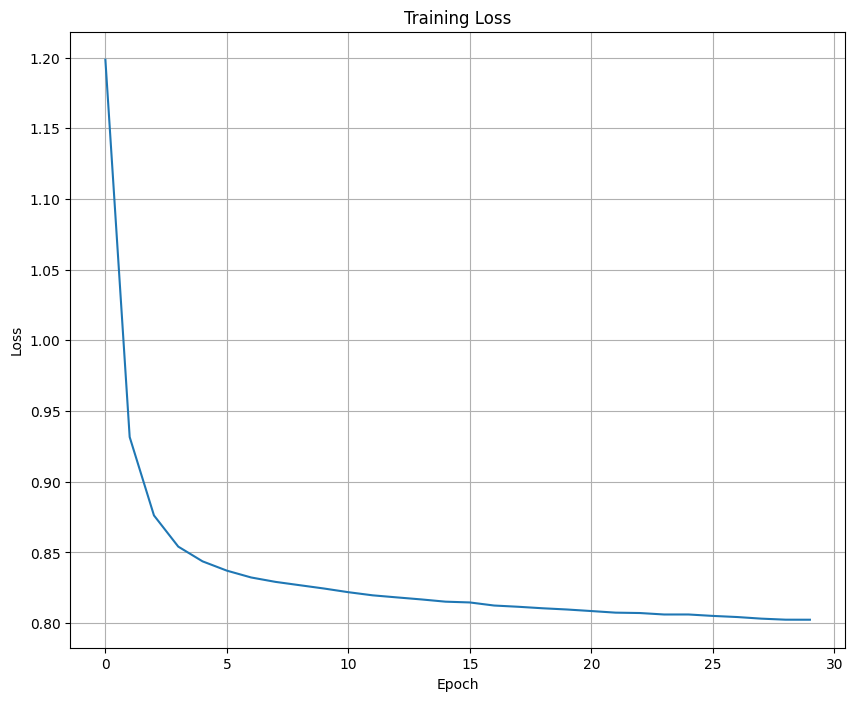


Generating sample text...

Seed: `alice`
alice, there were time, and then i seplunate on the parches in the little dograning it were the hatter we

Seed: `the rabbit`
the rabbit again! latity came tea, evend confusion, alice to have thists anxeles here when she looked replied 

Seed: `once upon`
once upon a tree court overill she spoke about it. she thought ela. as fellow! said alice, you can t sway the


In [12]:
main()